# **Proyecto 1 - ECOBICI**
Marcos Diaz 221102 y Daniel Machic 22118

## **Carga de librerías**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## **Carga e inspección de datos**

En esta sección se realiza la carga de los datos previamente procesados en formato `.parquet`, los cuales fueron generados a partir de la integración y limpieza de archivos mensuales entre enero de 2024 a marzo de 2026. El uso de archivos `.parquet` permite una lectura más eficiente y un mejor manejo de grandes volúmenes de datos.

### Carga de archivos parquet

In [ ]:
# Ruta de los archivos parquet
carpeta = os.path.expanduser("C:/Users/marcs/OneDrive/Documents/Github/Seminario-Proyecto1/Datos Ecobici")
archivos = glob.glob(os.path.join(carpeta, "*.parquet"))

columnas = [
    "Anio", "Mes", "Hora", "DiaSemana", "Es_FinDeSemana",
    "Duracion_Minutos", "Genero_Usuario", "Edad_Usuario",
    "Ciclo_Estacion_Retiro"
]

df = pd.concat(
    [pd.read_parquet(f, columns=columnas, engine="pyarrow") for f in archivos],
    ignore_index=True
)

# Dimensión del dataset
df.shape

ArrowKeyError: A type extension with name pandas.period already defined

### Inspeccion del dataset

In [6]:
print("Dimensión del dataset:")
print(df.shape)

print("\nVista inicial:")
print(df.head())

print("\nEstructura y tipos de datos:")
df.info()

print("\nEstadísticas descriptivas:")
print(df.describe())

print("\nValores faltantes por columna:")
print(df.isnull().sum())

Dimensión del dataset:


NameError: name 'df' is not defined

El dataset consolidado contiene un total de aproximadamente 47 millones de registros, lo cual representa un volumen considerable de información sobre el uso del sistema ECOBICI en el período analizado. En términos de estructura, se observa que las variables han sido correctamente tipificadas, incluyendo variables numéricas (año, mes, hora, duración), categóricas (género, estación) y una variable booleana que indica si el viaje se realizó en fin de semana. 

A partir de las estadísticas descriptivas, se identifica que:
- La duración promedio de los viajes es de aproximadamente 15 minutos, lo cual sugiere un uso mayoritariamente de trayectos cortos.
- La distribución de la hora indica una concentración alrededor de las 14:00 horas, lo cual puede asociarse a patrones de movilidad urbana.
- La edad promedio de los usuarios es cercana a los 34 años, concentrándose principalmente entre los 27 y 39 años.

En relación con la calidad de los datos, se observa que la cantidad de valores faltantes es relativamente baja en comparación con el tamaño total del dataset. En particular:
- La variable `Genero_Usuario` presenta una cantidad mínima de valores faltantes.
- La variable `Edad_Usuario` presenta algunos valores nulos, pero no representan una proporción significativa del total.

Finalmente, se detecta la presencia de valores extremos en la edad (hasta 160 años), lo cual sugiere la existencia de posibles outliers que deberán ser tratados en la siguiente etapa de limpieza de datos.

## **Preparación y limpieza de datos**

La preparación de los datos se desarrolló en dos etapas. En primer lugar, se realizó un script en Python denominado `Proyecto1-Seminario2.py`, cuyo propósito fue procesar los archivos mensuales originales en formato CSV y convertirlos a formato `.parquet`, corrigiendo inconsistencias y generando variables derivadas relevantes para el análisis. Entre las tareas realizadas destacan:

- integración de múltiples archivos mensuales (de enero 2024 a marzo 2026)
- normalización de nombres de columnas
- corrección de inconsistencias en encabezados
- transformación de valores nulos codificados como texto
- conversión de tipos de datos
- generación de variables temporales y de duración
- filtrado inicial de registros inválidos
- exportación de los datos procesados a formato `.parquet`

### Tratamiento de valores faltantes

In [ ]:
df = df[df["Duracion_Minutos"].notna()]
df = df[df["Hora"].notna()]

### Filtrado de valores atípicos en duración y edad

In [ ]:
# Para ser un análisis enfocado en la movilidad de las personas se limitaron los recorridos a 120 mins maximo
df = df[(df["Duracion_Minutos"] >= 0) & (df["Duracion_Minutos"] <= 120)]

In [ ]:
# Para ser un análisis más razonable se limitó la edad a 80 y mayor a 10
df = df[
    (df["Edad_Usuario"].isna()) |
    ((df["Edad_Usuario"] >= 10) & (df["Edad_Usuario"] <= 80))
]

### Verificación de registros duplicados

In [ ]:
duplicados = df.duplicated().sum()
print("Registros duplicados:", duplicados)

Registros duplicados: 48845


In [ ]:
df = df.drop_duplicates()

### Tipos de datos correctos

In [ ]:
df["Anio"] = df["Anio"].astype("int32")
df["Mes"] = df["Mes"].astype("int8")
df["Hora"] = df["Hora"].astype("int8")
df["DiaSemana"] = df["DiaSemana"].astype("int8")
df["Edad_Usuario"] = df["Edad_Usuario"].astype("Int64")
df["Es_FinDeSemana"] = df["Es_FinDeSemana"].astype("bool")
df["Ciclo_Estacion_Retiro"] = df["Ciclo_Estacion_Retiro"].astype("category")

Durante esta etapa se eliminaron registros con valores atípicos en la duración de los viajes (entre 0 a 120 minutos), se validaron rangos razonables en la edad de los usuarios (limitado entre 10 a 80 años) y se verificó la presencia de valores faltantes. Asimismo, se identificaron aproximadamente 48,845 registros duplicados, los cuales representan una proporción inferior al 0.1% del total de datos, por lo que fueron eliminados para evitar redundancias. 

## **Análisis exploratorio de datos**

#### Cantidad de viajes por hora del día 

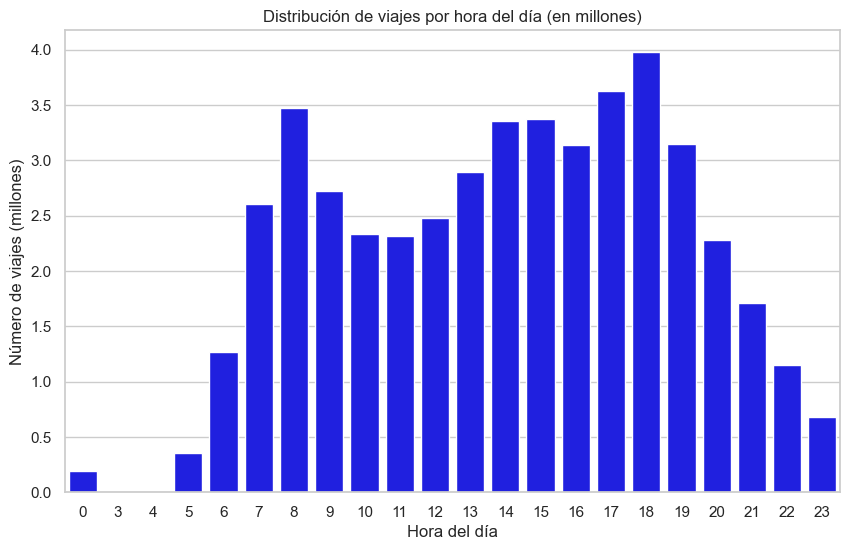

In [ ]:
# Cantidad de viajes por hora del día (millones)
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Hora"], engine="pyarrow")
    conteo = temp.groupby("Hora").size().reset_index(name="Viajes")
    partes.append(conteo)

uso_hora = pd.concat(partes, ignore_index=True)
uso_hora = uso_hora.groupby("Hora", as_index=False)["Viajes"].sum()
uso_hora["Viajes_Millones"] = uso_hora["Viajes"] / 1_000_000
uso_hora["Hora"] = uso_hora["Hora"].astype(int)

sns.barplot(data=uso_hora, x="Hora", y="Viajes_Millones", color="blue")
plt.title("Distribución de viajes por hora del día (en millones)")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes (millones)")
plt.show()


La distribución de viajes por hora del día muestra un patrón claramente definido en el uso del sistema ECOBICI, evidenciando comportamientos asociados a la movilidad urbana. Se observa un incremento significativo en la actividad a partir de las 6:00 horas, alcanzando un primer pico entre las 7:00 y 9:00 horas, con más de 3 millones de viajes en el punto más alto. Este comportamiento concuerda con los horarios de inicio de la jornada laboral. Luego, se mantiene un nivel alto de uso durante el día, con valores mayores a los 2 millones de viajes entre las 10:00 y las 16:00 horas. El segundo y más pronunciado pico ocurre entre las 17:00 y 18:00 horas, alcanzando cerca de 4 millones de viajes, lo cual coincide con el horario de salida laboral. Finalmente, se observa una disminución progresiva a partir de las 19:00 horas, con muy pocos viajes durante la madrugada, lo que refleja una baja actividad en horarios nocturnos.

#### Viajes por hora: semana vs fin de semana 

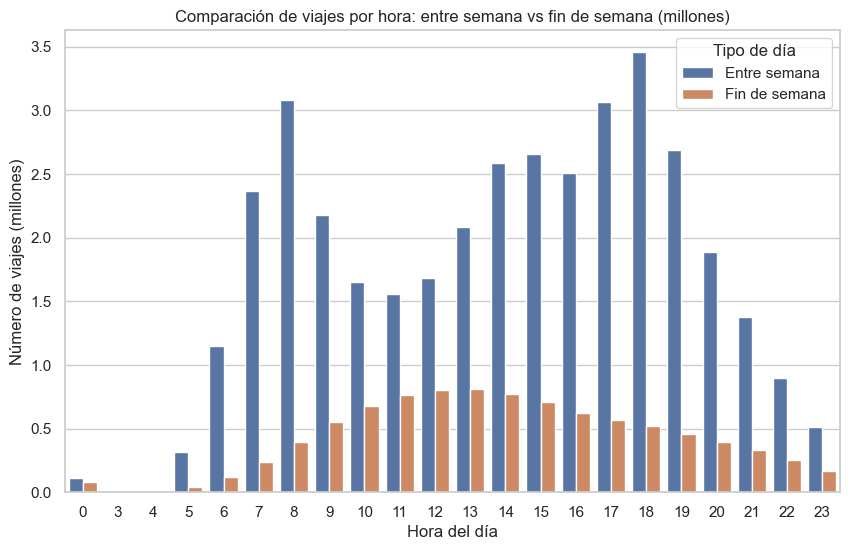

In [ ]:
# Viajes por hora: semana vs fin de semana (millones)
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Hora", "Es_FinDeSemana"], engine="pyarrow")
    
    temp["Hora"] = temp["Hora"].astype(int)
    
    conteo = temp.groupby(["Hora", "Es_FinDeSemana"]).size().reset_index(name="Viajes")
    partes.append(conteo)

uso_semana = pd.concat(partes, ignore_index=True)
uso_semana = uso_semana.groupby(["Hora", "Es_FinDeSemana"], as_index=False)["Viajes"].sum()
uso_semana["Viajes_Millones"] = uso_semana["Viajes"] / 1_000_000

uso_semana["Tipo_Dia"] = uso_semana["Es_FinDeSemana"].map({
    False: "Entre semana",
    True: "Fin de semana"
})

sns.barplot(data=uso_semana, x="Hora", y="Viajes_Millones", hue="Tipo_Dia")

plt.title("Comparación de viajes por hora: entre semana vs fin de semana (millones)")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes (millones)")
plt.legend(title="Tipo de día")
plt.show()

El análisis comparativo entre días de semana y fines de semana revela diferencias claras en los patrones de uso del sistema ECOBICI, evidenciando comportamientos asociados tanto a la movilidad laboral como a actividades recreativas. Durante los días entre semana, se observa un patrón de uso fuertemente estructurado, con dos picos bien definidos. El primero ocurre en horas de la mañana, entre las 7:00 y 9:00, alcanzando los 3 millones de viajes, lo cual coincide con el inicio de la jornada laboral. El segundo y más pronunciado pico se presenta en horas de la tarde, principalmente entre las 17:00 y 18:00, superando los 3.4 millones de viajes, asociado al retorno a los hogares.

En contraste, los fines de semana presentan un comportamiento significativamente diferente. El uso es más distribuido a lo largo del día, con un incremento gradual a partir de la mañana y un pico más moderado alrededor del mediodía y primeras horas de la tarde, alcanzando aproximadamente entre 700 mil y 800 mil viajes. No se observan picos tan marcados como en los días laborales. Además, el volumen total de viajes durante los fines de semana es considerablemente menor en comparación con los días entre semana en todas las franjas horarias, lo que refuerza la idea de que el sistema es utilizado principalmente como medio de transporte funcional durante días laborales.

#### Cantidad de viajes por día de la semana 

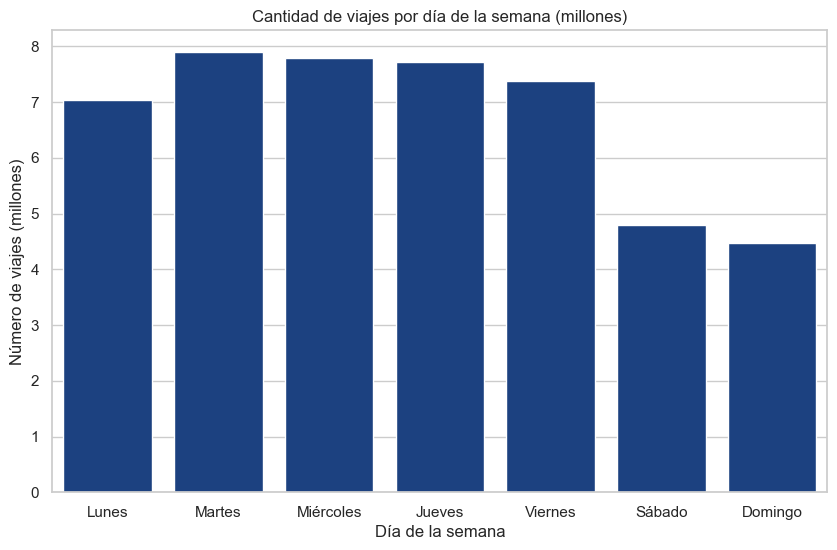

In [ ]:
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["DiaSemana"], engine="pyarrow")
    temp["DiaSemana"] = temp["DiaSemana"].astype(int)
    
    conteo = temp.groupby("DiaSemana").size().reset_index(name="Viajes")
    partes.append(conteo)

uso_dia = pd.concat(partes, ignore_index=True)
uso_dia = uso_dia.groupby("DiaSemana", as_index=False)["Viajes"].sum()
uso_dia["Viajes_Millones"] = uso_dia["Viajes"] / 1_000_000

mapa_dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

uso_dia["Dia"] = uso_dia["DiaSemana"].map(mapa_dias)

sns.barplot(data=uso_dia, x="Dia", y="Viajes_Millones", color="#0B3D91")
plt.title("Cantidad de viajes por día de la semana (millones)")
plt.xlabel("Día de la semana")
plt.ylabel("Número de viajes (millones)")

plt.show()

Se observa que los días entre semana tiene la mayor cantidad de viajes, destacando el martes como el día con mayor actividad, con aproximadamente 7,893,040 viajes. De manera general, el período comprendido entre lunes y jueves mantiene niveles relativamente estables, todos por encima de los 7,700,000 viajes, lo que refleja un uso intensivo y constante del sistema durante la semana laboral. El viernes presenta una ligera disminución, con alrededor de 7,371,883 viajes, lo cual puede estar asociado a cambios en los patrones de movilidad al final de la semana. Por otra parte, los fines de semana muestran una caída significativa en el número de viajes, con una reducción aproximada del 40% en viajes. El sábado registra aproximadamente 4,802,998 viajes, mientras que el domingo presenta el menor volumen con 4,464,950 viajes. Esta reducción considerable evidencia una menor demanda del sistema en días no laborales. Se puede concluir que el sistema de ECOBICI es utilizado principalmente como medio de transporte funcional durante la semana, mientras que su uso disminuye en fines de semana.

#### Cantidad de viajes por rango de duración (en minutos)

In [ ]:
bins = [0, 5, 10, 20, 30, 60, 120]
labels = ["0-5", "5-10", "10-20", "20-30", "30-60", "60-120"]
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Duracion_Minutos"], engine="pyarrow")
    temp = temp.dropna()
    
    temp["Rango"] = pd.cut(temp["Duracion_Minutos"], bins=bins, labels=labels)
    conteo = temp.groupby("Rango").size().reset_index(name="Viajes")
    
    partes.append(conteo)

uso_duracion = pd.concat(partes, ignore_index=True)
uso_duracion = uso_duracion.groupby("Rango", as_index=False)["Viajes"].sum()
uso_duracion["Viajes_Millones"] = uso_duracion["Viajes"] / 1_000_000

sns.barplot(data=uso_duracion, x="Rango", y="Viajes_Millones", color="#5DADE2")
plt.title("Distribución de viajes por rango de duración")
plt.xlabel("Duración del viaje (minutos)")
plt.ylabel("Número de viajes (millones)")

plt.show()

Se observa que el mayor volumen de viajes se concentra en el rango de 10 a 20 minutos, con aproximadamente 16,210,138 viajes, seguido por el rango de 5 a 10 minutos con 13,291,555 viajes. Estos dos rangos de tiempo representan la mayor parte del uso del sistema, lo que indica que los usuarios realizan trayectos cortos. El rango de 0 a 5 minutos también presenta una cantidad significativa de viajes, con alrededor de 5,752,126 viajes. A medida que aumenta la duración, se observa una disminución constante en el número de viajes. El rango de 20 a 30 minutos registra aproximadamente 7,012,129 viajes, mientras que los viajes entre 30 y 60 minutos descienden a 4,595,003. Finalmente, los viajes de larga duración (entre 60 y 120 minutos) representan una parte mínima del total, con solo 183,610 registros, lo cual sugiere que este tipo de trayectos es poco común. Se puede concluir que el sistema ECOBICI es utilizado mayormente para trayectos cortos.

#### Cantidad de viajes por rango de edad

In [ ]:
bins = [10, 20, 30, 40, 50, 60, 80]
labels = ["10-20", "20-30", "30-40", "40-50", "50-60", "60-80"]
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Edad_Usuario"], engine="pyarrow")
    temp = temp.dropna()
    
    temp["Rango"] = pd.cut(temp["Edad_Usuario"], bins=bins, labels=labels)
    conteo = temp.groupby("Rango").size().reset_index(name="Viajes")
    
    partes.append(conteo)

uso_edad = pd.concat(partes, ignore_index=True)
uso_edad = uso_edad.groupby("Rango", as_index=False)["Viajes"].sum()
uso_edad["Viajes_Millones"] = uso_edad["Viajes"] / 1_000_000

sns.barplot(data=uso_edad, x="Rango", y="Viajes_Millones")
plt.title("Distribución de viajes por rango de edad (millones)")
plt.xlabel("Rango de edad")
plt.ylabel("Número de viajes (millones)")

plt.show()


Se observa que el mayor volumen de viajes se concentra en el rango de 20 a 30 años, con 18,844,537 viajes, seguido por el grupo de 30 a 40 años con 16,881,585 viajes. En conjunto, estos dos segmentos representan la gran mayoría del uso del sistema, evidenciando una fuerte concentración en adultos jóvenes. El grupo de 40 a 50 años también presenta una participación relevante, con alrededor de 6,527,983 viajes, aunque significativamente menor en comparación con los grupos más jóvenes. Por otro lado, los extremos de la distribución muestran una menor participación. El rango de 10 a 20 años registra aproximadamente 1,332,297 viajes, mientras que los usuarios entre 60 y 80 años representan el menor volumen, con 833,269 viajes. Esto sugiere una menor adopción del sistema en personas más jóvenes y de mayor edad. Estos resultados indican que el sistema ECOBICI es utilizado mayormente por adultos jóvenes.

#### Top 10 estaciones más utilizadas

In [ ]:
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Ciclo_Estacion_Retiro"], engine="pyarrow")
    conteo = temp["Ciclo_Estacion_Retiro"].value_counts().reset_index()
    conteo.columns = ["Estacion", "Viajes"]
    partes.append(conteo)

top_estaciones = pd.concat(partes, ignore_index=True)
top_estaciones = top_estaciones.groupby("Estacion", as_index=False)["Viajes"].sum()
top_estaciones = top_estaciones.sort_values("Viajes", ascending=False).head(10)
top_estaciones["Viajes_Millones"] = top_estaciones["Viajes"] 

sns.barplot(data=top_estaciones, x="Viajes_Millones", y="Estacion", color="#1F4E79")
plt.title("Top 10 estaciones con mayor número de viajes (millones)")
plt.xlabel("Cantidad de viajes")
plt.ylabel("Estación")

plt.show()

Se observa que la estación con mayor demanda corresponde al identificador "271-272", con aproximadamente 410,750 viajes, la cual, según el catálogo de estaciones, se ubica en la zona de “Jesús García - Carlos J. Meneses”. De manera similar, otras estaciones destacadas como la "064" (Sonora - Ámsterdam) y la "014" o "031" se localizan en áreas urbanas consolidadas con alta actividad. Algo importante a destacar es la presencia de estaciones con identificadores compuestos (por ejemplo, "271-272" o "237-238"), las cuales representan puntos con mayor capacidad o integración de múltiples estaciones en una misma ubicación. Esto sugiere que los nodos de mayor demanda no son puntos aislados, sino zonas estratégicas dentro de la red de movilidad. Además, al observar los nombres de las estaciones, se identifica que muchas de ellas se ubican en intersecciones relevantes o corredores urbanos importantes (como avenidas principales, ejes viales o zonas de alta densidad). La diferencia entre la estación más utilizada y las siguientes no es mucha, lo que indica que, aunque existen puntos de alta demanda, el sistema mantiene una distribución relativamente equilibrada entre sus principales estaciones.

#### Cantidad de viajes por año 

In [ ]:
 partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Anio"], engine="pyarrow")
    temp["Anio"] = temp["Anio"].astype(int)
    
    conteo = temp.groupby("Anio").size().reset_index(name="Viajes")
    partes.append(conteo)

viajes_anio = pd.concat(partes, ignore_index=True)
viajes_anio = viajes_anio.groupby("Anio", as_index=False)["Viajes"].sum()
viajes_anio["Viajes_Miles"] = viajes_anio["Viajes"] / 1_000_000
viajes_anio = viajes_anio.sort_values("Anio")
viajes_anio = viajes_anio[viajes_anio["Anio"] >= 2024]

sns.lineplot(data=viajes_anio, x="Anio", y="Viajes_Miles", marker="o", color="#1F4E79")
plt.title("Evolución de viajes por año (miles)")
plt.xlabel("Año")
plt.ylabel("Número de viajes (miles)")
plt.xticks(viajes_anio["Anio"])

plt.show()

Se observa que en el año 2024 se registran aproximadamente 22,238,631 viajes, siendo el valor más alto dentro del período analizado. Para el año 2025, se presenta una ligera disminución, alcanzando cerca de 20,131,152 viajes. Aunque existe una reducción, el nivel de uso se mantiene elevado, lo que sugiere una estabilidad en la demanda del sistema. Por su parte, el año 2026 registra 4,706,346 viajes. Sin embargo, este valor no es directamente comparable con los años anteriores, ya que corresponde a solo 3 meses del presente año.

#### Uso por hora por año

In [ ]:
partes = []

for f in archivos:
    temp = pd.read_parquet(f, columns=["Anio", "Hora"], engine="pyarrow")
    
    temp["Anio"] = temp["Anio"].astype(int)
    temp["Hora"] = temp["Hora"].astype(int)
    
    conteo = temp.groupby(["Anio", "Hora"]).size().reset_index(name="Viajes")
    partes.append(conteo)

uso_hora_anio = pd.concat(partes, ignore_index=True)
uso_hora_anio = uso_hora_anio.groupby(["Anio", "Hora"], as_index=False)["Viajes"].sum()
uso_hora_anio = uso_hora_anio[uso_hora_anio["Anio"] >= 2024]
uso_hora_anio["Viajes_Miles"] = uso_hora_anio["Viajes"] / 1_000_000

sns.lineplot(
    data=uso_hora_anio,
    x="Hora",
    y="Viajes_Miles",
    hue="Anio",
    marker="o"
)

plt.title("Uso por hora del día según el año (miles)")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes (miles)")
plt.legend(title="Año")
plt.xticks(range(0, 24))

plt.show()

Se observa que, sin importar del año, el sistema mantiene una estructura de uso muy similar, con un incremento progresivo a partir de las primeras horas de la mañana, alcanzando un primer pico en el rango de 7:00 a 9:00 horas. Posteriormente, el uso se mantiene relativamente alto durante el día, seguido por un segundo pico más pronunciado en horas de la tarde, particularmente entre las 17:00 y 18:00. Este patrón se repite de manera consistente en todos los años analizados, lo que indica que la dinámica de uso del sistema no ha cambiado con en el tiempo. A pesar de las diferencias en el volumen total de viajes entre años, la forma de la distribución horaria se mantiene estable.

## **Clusterización con K-Means**

In [ ]:
df_estaciones = (
    df.groupby("Ciclo_Estacion_Retiro")
    .agg(
        Total_Viajes=("Ciclo_Estacion_Retiro", "count"),
        Hora_Promedio=("Hora", "mean"),
        Duracion_Promedio=("Duracion_Minutos", "mean"),
        Edad_Promedio=("Edad_Usuario", "mean"),
        Proporcion_FinDeSemana=("Es_FinDeSemana", "mean")
    )
    .reset_index()
)

df_estaciones["Edad_Promedio"] = df_estaciones["Edad_Promedio"].fillna(df_estaciones["Edad_Promedio"].mean())

# Variables para clustering
X = df_estaciones[[
    "Total_Viajes",
    "Hora_Promedio",
    "Duracion_Promedio",
    "Edad_Promedio",
    "Proporcion_FinDeSemana"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Grafica de codo
inertia = []

for k in range(1, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 7), inertia, marker="o", color="#1F4E79")
plt.title("Método del codo para clustering por estación")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.xticks(range(1, 7))
plt.show()

# K Means
kmeans_est = KMeans(n_clusters=3, random_state=42, n_init=10)
df_estaciones["Cluster"] = kmeans_est.fit_predict(X_scaled)

print("\nCentroides promedio por cluster:")
print(df_estaciones.groupby("Cluster")[[
    "Total_Viajes",
    "Hora_Promedio",
    "Duracion_Promedio",
    "Edad_Promedio",
    "Proporcion_FinDeSemana"
]].mean())

print("\nCantidad de estaciones por cluster:")
print(df_estaciones["Cluster"].value_counts().sort_index())

## **PCA**

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_estaciones["PC1"] = X_pca[:, 0]
df_estaciones["PC2"] = X_pca[:, 1]

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nVarianza explicada acumulada:")
print(pca.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_estaciones,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=70,
    alpha=0.85
)

plt.title("Visualización de clusters por estación mediante PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster")
plt.show()

cargas_pca = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=[
        "Total_Viajes",
        "Hora_Promedio",
        "Duracion_Promedio",
        "Edad_Promedio",
        "Proporcion_FinDeSemana"
    ]
)

## **Resultados de K-Means y PCA**

A partir del método del codo se determinó que tres clusters representan adecuadamente la segmentación de las estaciones, ya que a partir de este punto la reducción en la inercia comienza a estabilizarse. Los resultados evidencian la existencia de **tres tipos principales de estaciones**. El primer grupo corresponde a **estaciones de alta demanda**, caracterizadas por un volumen significativamente mayor de viajes, lo que sugiere que funcionan como nodos clave dentro del sistema. El segundo grupo se asocia a **estaciones con uso prolongado**, donde la duración promedio de los viajes es mayor, indicando posibles trayectos más largos o distintos patrones de movilidad. Finalmente, el tercer grupo representa **estaciones de uso estándar**, con niveles moderados de actividad y características promedio del sistema.

En general, la edad promedio de los usuarios no presenta diferencias relevantes entre los clusters, lo que indica que esta variable no es determinante en la segmentación a nivel de estaciones. La aplicación de PCA permitió visualizar los clusters en un espacio bidimensional. La varianza explicada acumulada es cercana al 50%, lo cual indica que la representación captura aproximadamente la mitad de la información original del dataset. Si bien esto implica una simplificación de los datos, resulta suficiente para identificar tendencias generales y observar la distribución de los clusters.

La visualización muestra una separación parcial entre los grupos, lo cual es consistente con la naturaleza continua de los datos de movilidad urbana, donde las estaciones pueden compartir características similares y no presentan divisiones completamente marcadas llegando incluso a sobreponerse pero si es posible identificar una diferencia para cada cluster. En conclusión, se ve que las estaciones pueden clasificarse según su intensidad de uso y características operativas, permitiendo identificar nodos de alta demanda, patrones diferenciados de movilidad y una estructura funcional dentro del sistema ECOBICI.

## **Mapa con visualización de clusters**

In [ ]:
import json
import pandas as pd
import folium

json_path = "station_information.json"  # ajusta ruta

with open(json_path, "r", encoding="utf-8") as f:
    station_json = json.load(f)

stations = pd.DataFrame(station_json["data"]["stations"])

stations = stations[["short_name", "name", "lat", "lon", "capacity"]].copy()

stations["short_name"] = stations["short_name"].astype(str).str.strip().str.zfill(3)

df_estaciones["Ciclo_Estacion_Retiro"] = df_estaciones["Ciclo_Estacion_Retiro"].astype(str).str.strip()

map_df = stations.merge(
    df_estaciones,
    left_on="short_name",
    right_on="Ciclo_Estacion_Retiro",
    how="inner"
)

print("Estaciones con cluster:", len(map_df))

cluster_colors = {
    0: "red",
    1: "blue",
    2: "green"
}

center_lat = map_df["lat"].mean()
center_lon = map_df["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

for _, row in map_df.iterrows():
    
    color = cluster_colors.get(row["Cluster"], "gray")
    
    popup_text = f"""
    <b>Estación:</b> {row['name']}<br>
    <b>Código:</b> {row['short_name']}<br>
    <b>Cluster:</b> {row['Cluster']}<br>
    <b>Viajes:</b> {int(row['Total_Viajes'])}<br>
    <b>Duración promedio:</b> {round(row['Duracion_Promedio'],2)} min
    """
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(m)


m.save("mapa_clusters_estaciones.html")

print("Mapa guardado como mapa_clusters_estaciones.html")

## **Análisis del mapa**

La visualización espacial de los clusters permite identificar patrones geográficos en el uso del sistema ECOBICI. Se observa que las estaciones clasificadas en el cluster 2 (color verde), pertenecientes al cluster de alta demanda, se concentran principalmente en zonas centrales de la ciudad, evidenciando su papel como puntos clave de movilidad. Por su parte, las estaciones del cluster 0 (color rojo), asociadas a uso prolongado, tienden a ubicarse en áreas periféricas (o en los bordes del areá donde esta implementado ECOBICI), lo que sugiere trayectos más largos. Finalmente, el cluster 1 (color azul), correspondiente a uso estándar, se distribuye de manera más homogénea en toda la red, representando el comportamiento típico del sistema.